# Support Vector Machine – Drug Response Classification

## Pharmaceutical Industry Dataset

This assignment uses the same Drug Response Classification dataset . The SVM task asks for exploratory data analysis, preprocessing, visualization, SVM implementation, evaluation, result visualization, parameter tuning, and comparison of different kernels.

Target: `Drug Response`

0 = No Response

1 = Positive Response

The supplied SVM instructions specifically ask for EDA, feature distributions, correlations, train/test splitting, class-balance visualization, SVM classification, performance metrics, visualization of testing results, hyperparameter experiments, kernel comparison, and discussion of strengths, weaknesses, and practical implications.


## Assignment Tasks Covered

### Task 1 – Exploratory Data Analysis
- Load the dataset
- Basic exploration
- Histograms, box plots and density-style visualizations
- Feature correlations

### Task 2 – Data Preprocessing
- Check categorical variables
- Split into training and testing sets
- Standardize numerical variables because SVM is distance/margin based

### Task 3 – Data Visualization
- Feature distributions
- Pairwise relationships
- Class distribution

### Task 4 – SVM Implementation
- Basic SVM classifier
- Training
- Accuracy, precision, recall and F1-score

### Task 5 – Visualization of SVM Results
- Confusion matrix
- Two-dimensional visualization of the test predictions

### Task 6 – Parameter Tuning
- Different kernels
- Different values of `C`
- Different `gamma` values for RBF

### Task 7 – Comparison and Analysis
- Linear vs Polynomial vs RBF
- Strengths and weaknesses
- Practical implications


In [4]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report, roc_auc_score,
    ConfusionMatrixDisplay
)
from sklearn.decomposition import PCA

# Load the supplied dataset
df = pd.read_csv("/content/Pharma_Industry.csv")

print("Dataset shape:", df.shape)
display(df.head())


Dataset shape: (500, 6)


,Drug Dosage (mg),Systolic Blood Pressure (mmHg),Heart Rate (BPM),Liver Toxicity Index (U/L),Blood Glucose Level (mg/dL),Drug Response
0,-0.128538,0.303280,-1.881849,0.258286,-0.792011,1
1,-1.846188,2.865142,-0.929511,2.866786,-0.719447,1
2,-1.252393,-1.541613,0.363632,-0.325370,0.191314,0
3,1.992515,-1.142779,-0.766657,0.975286,-0.823355,1
4,0.377100,0.538410,-0.029263,1.896015,-0.960130,1


## 1. Basic Data Exploration

In [5]:
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

print("\nColumn names:")
print(df.columns.tolist())

print("\nData types:")
display(df.dtypes.to_frame("Data Type"))

print("\nSummary statistics:")
display(df.describe().T)

print("\nMissing values:")
display(df.isna().sum().to_frame("Missing Count"))

print("\nDuplicate rows:", df.duplicated().sum())


Rows: 500
Columns: 6

Column names:
['Drug Dosage (mg)', 'Systolic Blood Pressure (mmHg)', 'Heart Rate (BPM)', 'Liver Toxicity Index (U/L)', 'Blood Glucose Level (mg/dL)', 'Drug Response']

Data types:


,Data Type
Drug Dosage (mg),float64
Systolic Blood Pressure (mmHg),float64
Heart Rate (BPM),float64
Liver Toxicity Index (U/L),float64
Blood Glucose Level (mg/dL),float64
Drug Response,int64



Summary statistics:


,count,mean,std,min,25%,50%,75%,max
Drug Dosage (mg),500.0,-0.037761,0.979891,-3.019512,-0.642003,-0.019340,0.641151,2.949094
Systolic Blood Pressure (mmHg),500.0,0.214957,1.247567,-3.773897,-0.565168,0.201532,0.951375,4.111751
Heart Rate (BPM),500.0,0.062871,0.971978,-2.940389,-0.648157,0.027732,0.710774,3.193108
Liver Toxicity Index (U/L),500.0,0.054398,0.986001,-3.401277,-0.586085,-0.065661,0.633914,3.373269
Blood Glucose Level (mg/dL),500.0,-0.171863,0.983765,-3.110431,-0.797715,-0.108106,0.513555,2.518023
Drug Response,500.0,0.520000,0.500100,0.000000,0.000000,1.000000,1.000000,1.000000



Missing values:


,Missing Count
Drug Dosage (mg),0
Systolic Blood Pressure (mmHg),0
Heart Rate (BPM),0
Liver Toxicity Index (U/L),0
Blood Glucose Level (mg/dL),0
Drug Response,0



Duplicate rows: 0


### Initial observation

The supplied file contains 500 observations and five predictor variables plus the binary target. All predictors are numerical, so no categorical encoding is required for this particular dataset.

There are no missing values in the supplied file. Therefore, no imputation step is necessary.


## 2. Target/Class Distribution

The assignment asks for a visualization to determine whether the dataset is balanced or imbalanced.

,Count,Percentage
Drug Response,,
0,240,48.0
1,260,52.0


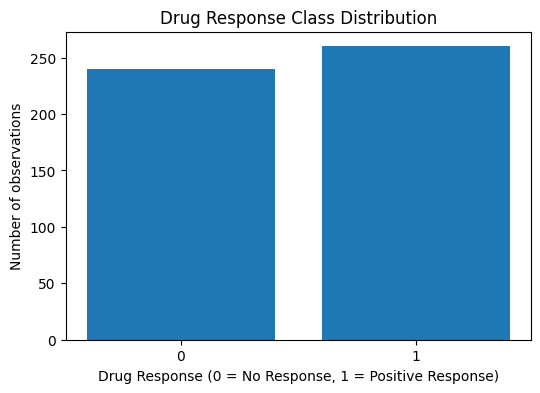

In [6]:
target_counts = df["Drug Response"].value_counts().sort_index()
target_percent = (target_counts / len(df) * 100).round(2)

target_table = pd.DataFrame({
    "Count": target_counts,
    "Percentage": target_percent
})
display(target_table)

plt.figure(figsize=(6,4))
plt.bar(target_counts.index.astype(str), target_counts.values)
plt.title("Drug Response Class Distribution")
plt.xlabel("Drug Response (0 = No Response, 1 = Positive Response)")
plt.ylabel("Number of observations")
plt.show()


## 3. Feature Distributions

Histograms help identify the shape and spread of each numerical variable. Box plots are also useful for spotting observations that are far from the middle of a distribution.

Because SVM can be affected by the scale of predictors, checking their distributions before preprocessing is useful.


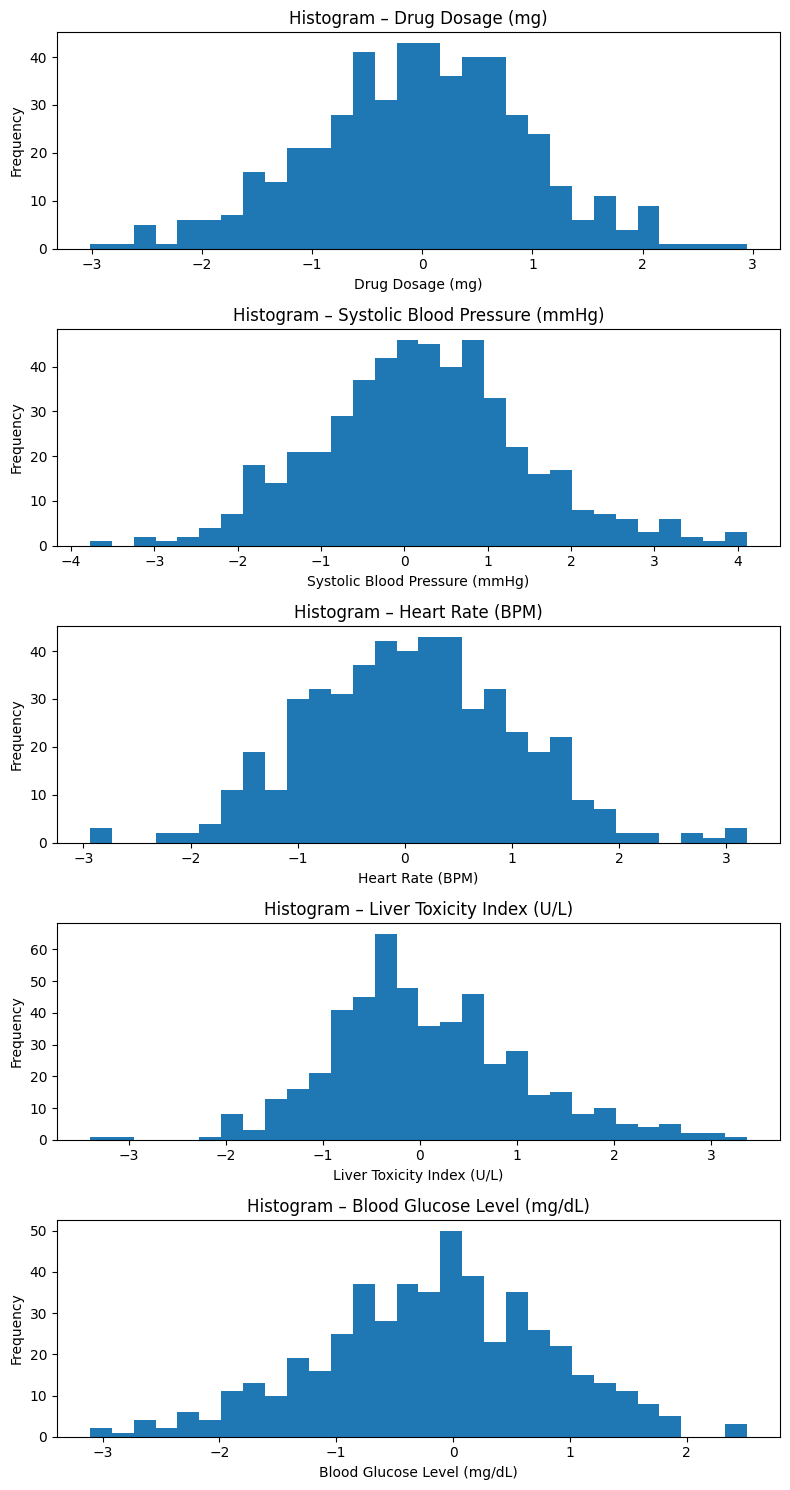

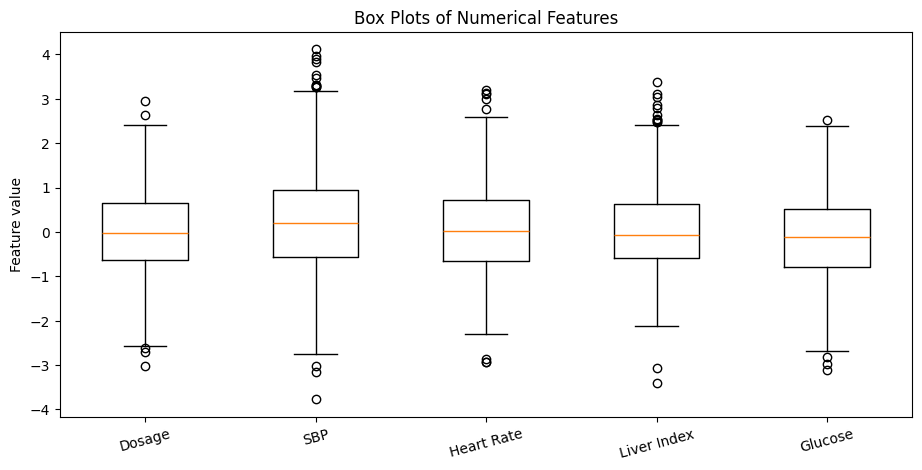

In [7]:
feature_cols = [
    "Drug Dosage (mg)",
    "Systolic Blood Pressure (mmHg)",
    "Heart Rate (BPM)",
    "Liver Toxicity Index (U/L)",
    "Blood Glucose Level (mg/dL)"
]

# Histograms
fig, axes = plt.subplots(len(feature_cols), 1, figsize=(8, 15))
for ax, col in zip(axes, feature_cols):
    ax.hist(df[col], bins=30)
    ax.set_title(f"Histogram – {col}")
    ax.set_xlabel(col)
    ax.set_ylabel("Frequency")
plt.tight_layout()
plt.show()

# Box plots
plt.figure(figsize=(11,5))
plt.boxplot([df[col] for col in feature_cols], labels=["Dosage","SBP","Heart Rate","Liver Index","Glucose"])
plt.title("Box Plots of Numerical Features")
plt.ylabel("Feature value")
plt.xticks(rotation=15)
plt.show()


## 4. Feature Correlation Analysis

Correlation measures the strength and direction of linear relationships between numerical variables. A value close to +1 indicates a strong positive linear relationship, while a value close to -1 indicates a strong negative linear relationship.

Correlation does not prove causation, and it does not capture every type of non-linear relationship.


,Drug Dosage (mg),Systolic Blood Pressure (mmHg),Heart Rate (BPM),Liver Toxicity Index (U/L),Blood Glucose Level (mg/dL),Drug Response
Drug Dosage (mg),1.000,0.091,0.041,0.128,0.012,0.043
Systolic Blood Pressure (mmHg),0.091,1.000,-0.039,0.284,0.037,0.305
Heart Rate (BPM),0.041,-0.039,1.000,0.006,0.050,-0.010
Liver Toxicity Index (U/L),0.128,0.284,0.006,1.000,0.229,0.435
Blood Glucose Level (mg/dL),0.012,0.037,0.050,0.229,1.000,0.169
Drug Response,0.043,0.305,-0.010,0.435,0.169,1.000


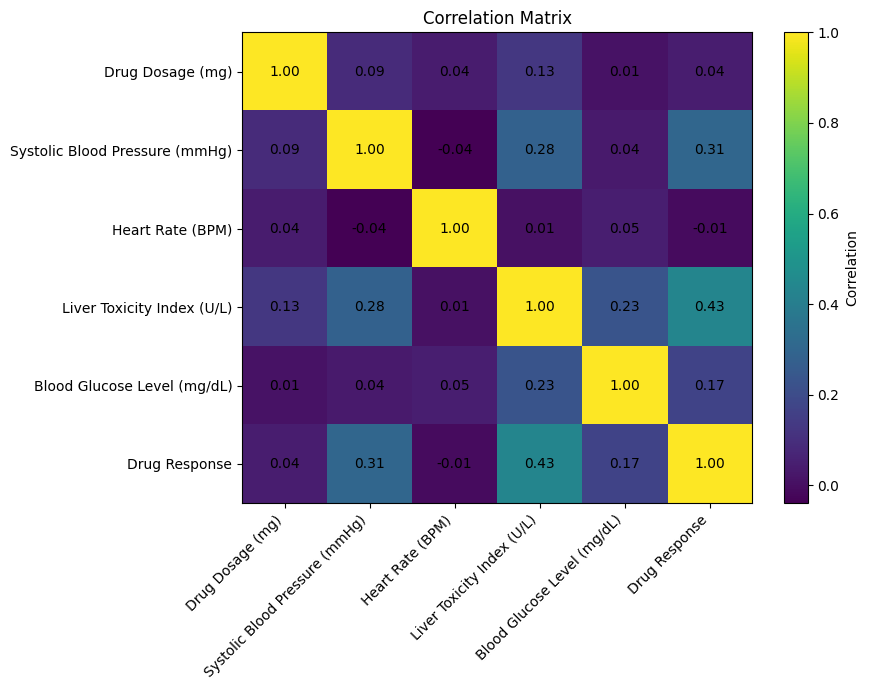

In [8]:
corr = df[feature_cols + ["Drug Response"]].corr()

display(corr.round(3))

plt.figure(figsize=(9,7))
plt.imshow(corr, aspect="auto")
plt.colorbar(label="Correlation")
plt.xticks(range(len(corr.columns)), corr.columns, rotation=45, ha="right")
plt.yticks(range(len(corr.index)), corr.index)

for i in range(len(corr.index)):
    for j in range(len(corr.columns)):
        plt.text(j, i, f"{corr.iloc[i,j]:.2f}", ha="center", va="center")

plt.title("Correlation Matrix")
plt.tight_layout()
plt.show()


## 5. Pairwise Visualization

A pair plot is useful for looking at relationships between several predictors and seeing whether the two response classes appear to form separate groups.

Here, the dataset has only five predictors, so a scatter-matrix style visualization is manageable.


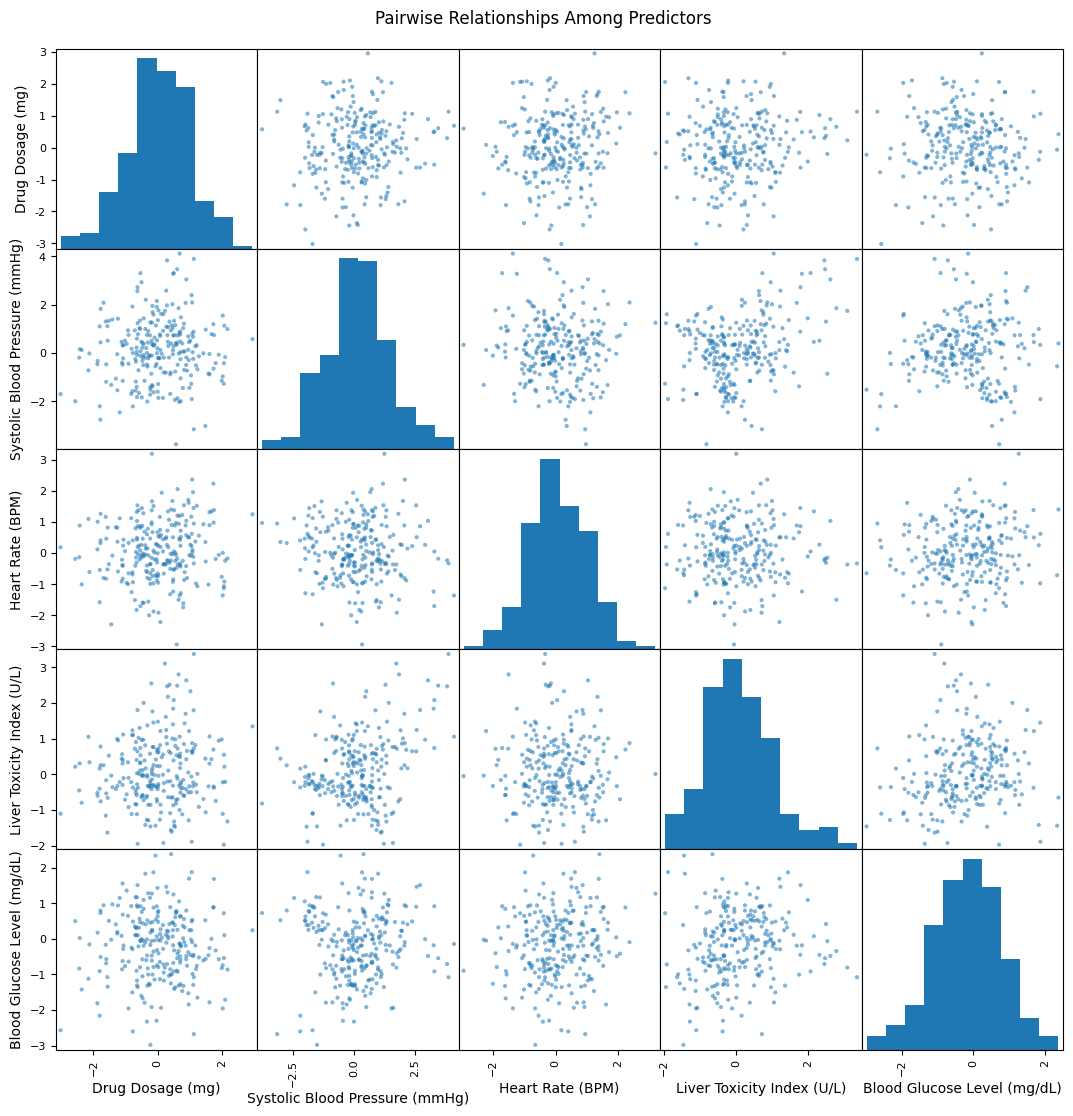

In [9]:
# Pairwise scatter plots for a compact sample of the dataset.
# The full pairwise matrix can be visually crowded, so this uses up to 250 observations.
sample_df = df.sample(min(250, len(df)), random_state=42)

pd.plotting.scatter_matrix(
    sample_df[feature_cols],
    figsize=(13,13),
    diagonal="hist",
    alpha=0.55
)
plt.suptitle("Pairwise Relationships Among Predictors", y=0.91)
plt.show()


## 6. Data Preprocessing

There are no categorical variables in the supplied dataset, so encoding is not required.

The predictors are numerical. I use StandardScalerbecause SVM classification depends on distances and the geometry of the separating margin. Standardization prevents a variable with a larger numerical scale from dominating the model.

The scaler is placed inside a Pipeline so that it is fitted only on the training data and then applied to the test data.


In [10]:
X = df[feature_cols].copy()
y = df["Drug Response"].copy()

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training set:", X_train.shape)
print("Testing set:", X_test.shape)

print("\nTraining class proportions:")
print(y_train.value_counts(normalize=True).sort_index().round(3))

print("\nTesting class proportions:")
print(y_test.value_counts(normalize=True).sort_index().round(3))


Training set: (400, 5)
Testing set: (100, 5)

Training class proportions:
Drug Response
0    0.48
1    0.52
Name: proportion, dtype: float64

Testing class proportions:
Drug Response
0    0.48
1    0.52
Name: proportion, dtype: float64


## 7. Basic SVM Classifier

I first train a basic SVM using the linear kernel. This gives a simple baseline before testing more flexible kernels.

 basic SVM classifier and evaluation using accuracy, precision, recall and F1-score.


In [11]:
linear_svm = Pipeline([
    ("scaler", StandardScaler()),
    ("svm", SVC(kernel="linear", C=1.0))
])

linear_svm.fit(X_train, y_train)

y_pred_linear = linear_svm.predict(X_test)

def classification_metrics(y_true, y_pred, model_name):
    return {
        "Model": model_name,
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred, zero_division=0),
        "Recall": recall_score(y_true, y_pred, zero_division=0),
        "F1 Score": f1_score(y_true, y_pred, zero_division=0)
    }

linear_results = classification_metrics(
    y_test, y_pred_linear, "Linear SVM"
)

display(pd.DataFrame([linear_results]).round(4))

print(classification_report(
    y_test, y_pred_linear,
    target_names=["No Response (0)", "Positive Response (1)"],
    zero_division=0
))


,Model,Accuracy,Precision,Recall,F1 Score
0,Linear SVM,0.72,0.7609,0.6731,0.7143


                       precision    recall  f1-score   support

      No Response (0)       0.69      0.77      0.73        48
Positive Response (1)       0.76      0.67      0.71        52

             accuracy                           0.72       100
            macro avg       0.72      0.72      0.72       100
         weighted avg       0.72      0.72      0.72       100



## 8. Linear SVM Confusion Matrix

,Predicted 0,Predicted 1
Actual 0,37,11
Actual 1,17,35


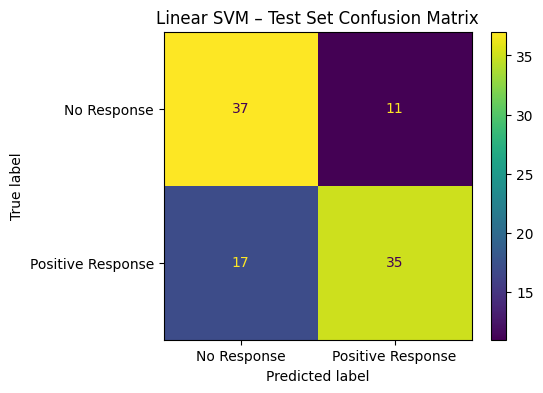

In [12]:
cm_linear = confusion_matrix(y_test, y_pred_linear)

display(pd.DataFrame(
    cm_linear,
    index=["Actual 0", "Actual 1"],
    columns=["Predicted 0", "Predicted 1"]
))

plt.figure(figsize=(5,4))
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_linear,
    display_labels=["No Response", "Positive Response"]
)
disp.plot(values_format="d", ax=plt.gca())
plt.title("Linear SVM – Test Set Confusion Matrix")
plt.show()


## 9. Visualizing SVM Test Results

The original feature space has five dimensions, so it cannot be shown directly in a normal two-dimensional scatter plot. I use PCA only for visualization, reducing the five standardized predictors to two principal components.

The SVM itself is still trained using all five original predictors. PCA is **not** replacing the actual model features here.


Variance explained by PC1: 0.2842
Variance explained by PC2: 0.2187
Total variance shown: 0.5029


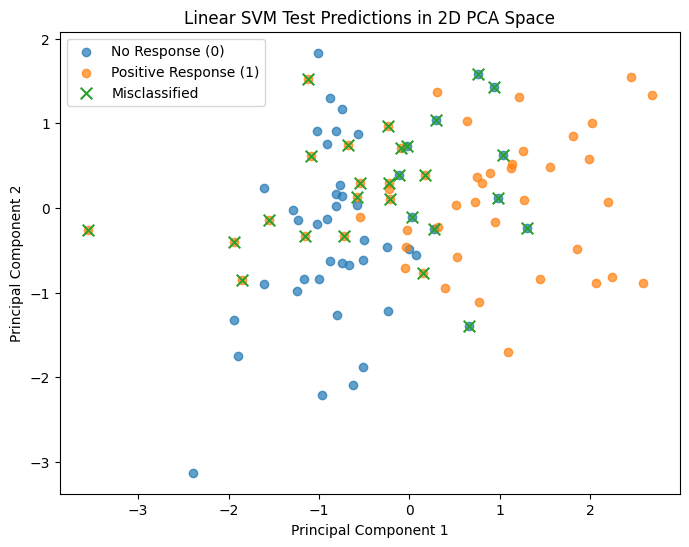

In [13]:
# Standardize the complete training/test feature space for visualization.
viz_scaler = StandardScaler()
X_train_scaled = viz_scaler.fit_transform(X_train)
X_test_scaled = viz_scaler.transform(X_test)

pca = PCA(n_components=2, random_state=42)
X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)

print("Variance explained by PC1:", round(pca.explained_variance_ratio_[0], 4))
print("Variance explained by PC2:", round(pca.explained_variance_ratio_[1], 4))
print("Total variance shown:", round(pca.explained_variance_ratio_.sum(), 4))

plt.figure(figsize=(8,6))
for cls, label in [(0, "No Response (0)"), (1, "Positive Response (1)")]:
    mask = y_test.to_numpy() == cls
    plt.scatter(
        X_test_pca[mask, 0],
        X_test_pca[mask, 1],
        label=label,
        alpha=0.7
    )

# Mark misclassified test observations
misclassified = y_test.to_numpy() != y_pred_linear
plt.scatter(
    X_test_pca[misclassified, 0],
    X_test_pca[misclassified, 1],
    marker="x",
    s=70,
    label="Misclassified"
)

plt.title("Linear SVM Test Predictions in 2D PCA Space")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.legend()
plt.show()


## 10. Kernel Comparison

- **Linear kernel**
- **Polynomial kernel**
- **Radial Basis Function (RBF) kernel**

### Linear kernel
Useful when the classes can be separated reasonably well with a linear decision boundary. It is relatively simple and fast.

### Polynomial kernel
Can model curved relationships through polynomial transformations. Its flexibility depends on parameters such as degree and `C`.

### RBF kernel
Can model more complex non-linear boundaries. It uses `gamma` to control how far the influence of each training observation reaches.


In [14]:
# Train baseline versions of the three requested kernels.
kernel_models = {
    "Linear SVM": Pipeline([
        ("scaler", StandardScaler()),
        ("svm", SVC(kernel="linear", C=1.0))
    ]),
    "Polynomial SVM": Pipeline([
        ("scaler", StandardScaler()),
        ("svm", SVC(kernel="poly", C=1.0, degree=3, gamma="scale"))
    ]),
    "RBF SVM": Pipeline([
        ("scaler", StandardScaler()),
        ("svm", SVC(kernel="rbf", C=1.0, gamma="scale"))
    ])
}

kernel_results = []

for name, model in kernel_models.items():
    model.fit(X_train, y_train)
    pred = model.predict(X_test)
    kernel_results.append(
        classification_metrics(y_test, pred, name)
    )

kernel_results_df = pd.DataFrame(kernel_results).set_index("Model")
display(kernel_results_df.round(4))


,Accuracy,Precision,Recall,F1 Score
Model,,,,
Linear SVM,0.72,0.7609,0.6731,0.7143
Polynomial SVM,0.65,0.6667,0.6538,0.6602
RBF SVM,0.77,0.7544,0.8269,0.7890


## 11. Kernel Performance Visualization

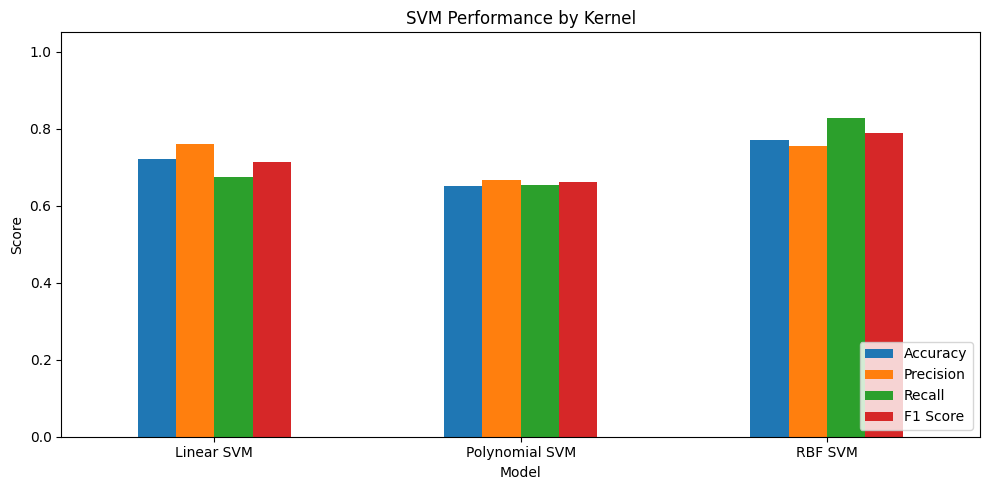

In [15]:
kernel_results_df.plot(
    kind="bar",
    figsize=(10,5),
    ylim=(0,1.05)
)

plt.title("SVM Performance by Kernel")
plt.ylabel("Score")
plt.xticks(rotation=0)
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()


## 12. Hyperparameter Tuning

SVM performance can change substantially depending on its hyperparameters.

For this assignment, I tune:

- `C`: controls the penalty for classification errors. Larger values place more emphasis on correctly classifying the training observations.
- `gamma`: controls the influence of individual observations for RBF and polynomial kernels.
- `degree`: controls polynomial complexity.

I use 5-fold cross-validation on the training set. The test set remains untouched until final evaluation.


In [16]:
# Parameter grid for the three requested kernel types.
param_grid = [
    {
        "svm__kernel": ["linear"],
        "svm__C": [0.1, 1, 10, 100]
    },
    {
        "svm__kernel": ["poly"],
        "svm__C": [0.1, 1, 10],
        "svm__degree": [2, 3, 4],
        "svm__gamma": ["scale", "auto"]
    },
    {
        "svm__kernel": ["rbf"],
        "svm__C": [0.1, 1, 10, 100],
        "svm__gamma": ["scale", "auto", 0.01, 0.1, 1]
    }
]

tuning_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("svm", SVC())
])

grid_search = GridSearchCV(
    tuning_pipeline,
    param_grid=param_grid,
    cv=5,
    scoring="f1",
    n_jobs=-1,
    return_train_score=False
)

grid_search.fit(X_train, y_train)

print("Best parameters:")
print(grid_search.best_params_)

print("\nBest cross-validation F1-score:",
      round(grid_search.best_score_, 4))


Best parameters:
{'svm__C': 1, 'svm__gamma': 1, 'svm__kernel': 'rbf'}

Best cross-validation F1-score: 0.7697


## 13. Final Tuned SVM Evaluation

After tuning on the training data, I evaluate the selected model once on the held-out test data. This provides an unbiased final estimate using observations that were not used during model fitting or cross-validation.


In [17]:
best_svm = grid_search.best_estimator_

y_pred_best = best_svm.predict(X_test)

# Probability-like scores are available using decision_function.
y_score_best = best_svm.decision_function(X_test)

best_results = classification_metrics(
    y_test, y_pred_best, "Tuned SVM"
)
best_results["ROC-AUC"] = roc_auc_score(y_test, y_score_best)

display(pd.DataFrame([best_results]).round(4))

print("Detailed classification report:")
print(classification_report(
    y_test,
    y_pred_best,
    target_names=["No Response (0)", "Positive Response (1)"],
    zero_division=0
))


,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Tuned SVM,0.72,0.7143,0.7692,0.7407,0.7624


Detailed classification report:
                       precision    recall  f1-score   support

      No Response (0)       0.73      0.67      0.70        48
Positive Response (1)       0.71      0.77      0.74        52

             accuracy                           0.72       100
            macro avg       0.72      0.72      0.72       100
         weighted avg       0.72      0.72      0.72       100



## 14. Tuned SVM Confusion Matrix and Test Results

,Predicted 0,Predicted 1
Actual 0,32,16
Actual 1,12,40


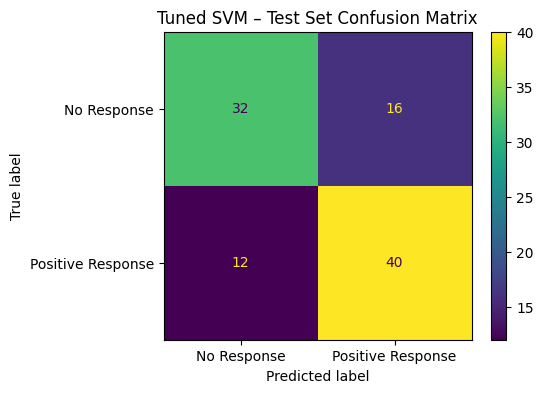

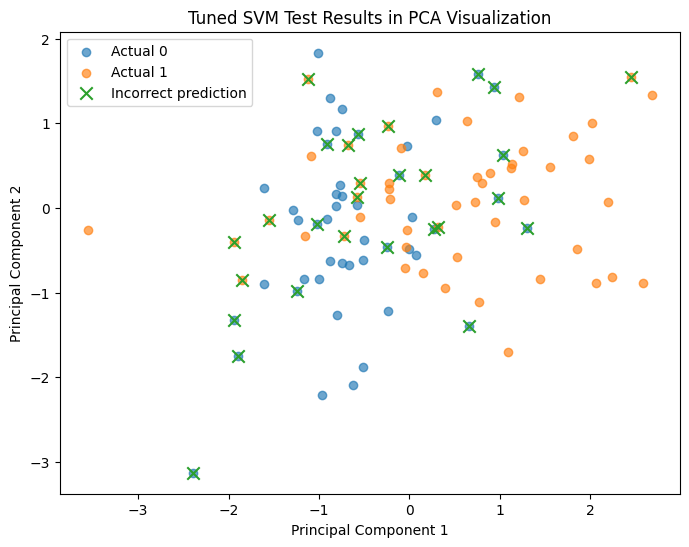

In [18]:
cm_best = confusion_matrix(y_test, y_pred_best)

display(pd.DataFrame(
    cm_best,
    index=["Actual 0", "Actual 1"],
    columns=["Predicted 0", "Predicted 1"]
))

plt.figure(figsize=(5,4))
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_best,
    display_labels=["No Response", "Positive Response"]
)
disp.plot(values_format="d", ax=plt.gca())
plt.title("Tuned SVM – Test Set Confusion Matrix")
plt.show()

# PCA visualization of tuned model predictions
plt.figure(figsize=(8,6))

for cls, label in [(0, "Actual 0"), (1, "Actual 1")]:
    mask = y_test.to_numpy() == cls
    plt.scatter(
        X_test_pca[mask, 0],
        X_test_pca[mask, 1],
        label=label,
        alpha=0.65
    )

# Mark incorrect predictions
misclassified_best = y_test.to_numpy() != y_pred_best
plt.scatter(
    X_test_pca[misclassified_best, 0],
    X_test_pca[misclassified_best, 1],
    marker="x",
    s=80,
    label="Incorrect prediction"
)

plt.title("Tuned SVM Test Results in PCA Visualization")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.legend()
plt.show()


## 15. Final Comparison of SVM Models

,Accuracy,Precision,Recall,F1 Score
Model,,,,
Linear SVM,0.72,0.7609,0.6731,0.7143
Polynomial SVM,0.65,0.6667,0.6538,0.6602
RBF SVM,0.77,0.7544,0.8269,0.7890
Tuned SVM,0.72,0.7143,0.7692,0.7407


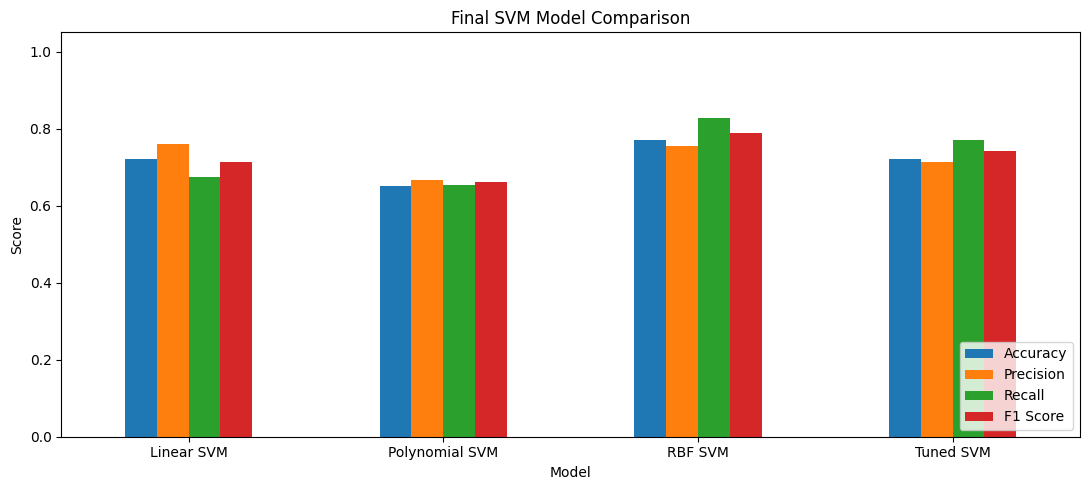

In [19]:
comparison = kernel_results_df.copy()
comparison.loc["Tuned SVM"] = pd.Series({
    "Accuracy": best_results["Accuracy"],
    "Precision": best_results["Precision"],
    "Recall": best_results["Recall"],
    "F1 Score": best_results["F1 Score"],
    "ROC-AUC": best_results["ROC-AUC"]
})

display(comparison.round(4))

comparison.plot(
    kind="bar",
    figsize=(11,5),
    ylim=(0,1.05)
)

plt.title("Final SVM Model Comparison")
plt.ylabel("Score")
plt.xticks(rotation=0)
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()


## 16. Analysis of SVM Strengths and Weaknesses

### Strengths

1. **Works well for classification:** SVM is specifically designed to find a separating boundary between classes.
2. **Effective in scaled numerical feature spaces:** The five predictors in this dataset can be standardized and used directly.
3. **Kernel flexibility:** The linear, polynomial, and RBF kernels allow the model to represent different types of class boundaries.
4. **Useful with moderate-sized datasets:** This dataset has only 500 observations, so SVM is practical to train and tune.
5. **Margin-based learning:** SVM focuses on the decision boundary and the observations that influence that boundary.

### Weaknesses

1. **Feature scaling is important:** Variables with very different scales can affect the geometry of the SVM.
2. **Hyperparameter sensitivity:** Choosing `C`, `gamma`, and kernel settings can change performance.
3. **Less directly interpretable than a simple linear model:** Especially with RBF and polynomial kernels.
4. **Computational cost can increase:** More complex SVM searches can become expensive as the number of observations grows.
5. **Clinical limitations:** A strong classification score on this small dataset does not mean the model is clinically validated.


## 17. Practical Pharmaceutical Implications

The dataset represents a drug-response classification problem where:

- **0 means no significant response**
- **1 means a positive response**

An SVM could potentially be used as a predictive support model to classify whether a patient is likely to respond positively based on dosage and measured biological variables.

For a real pharmaceutical application, the choice of evaluation metric should depend on the practical cost of errors. For example, if failing to identify a patient who could benefit from the drug is especially serious, recall for class 1 deserves attention. If false positive treatment recommendations are particularly costly or risky, precision is also important.

The model should not be considered a replacement for clinical trials, medical expertise, or regulatory validation. It would need independent validation, appropriate clinical data, careful bias assessment, and prospective evaluation before being considered for real-world use.


## 18. Final Conclusion

The complete SVM workflow was performed on the supplied pharmaceutical dataset.

The analysis included:

- Basic EDA and summary statistics
- Missing-value and duplicate checks
- Histograms and box plots
- Correlation analysis
- Pairwise visualization
- Class distribution analysis
- Train/test splitting with stratification
- Standardization of predictors
- A basic linear SVM
- Linear, polynomial, and RBF kernel comparison
- Accuracy, precision, recall, F1-score and ROC-AUC
- Confusion-matrix visualization
- PCA-based visualization of test predictions
- Hyperparameter tuning using cross-validation
- Final tuned SVM evaluation
- Strengths, weaknesses, and practical pharmaceutical implications

The final model should be selected based on the actual metrics displayed above rather than assuming that one kernel is always best. The tuned model is optimized using training-set cross-validation and then evaluated on the held-out test set.
